In [78]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from quantumScarFunctions import *
from quantumScarsPlotting import *
from densityFunctions import *

In [79]:
N = 10
tau_r = get_tau_r(N)
wd = 2*np.pi / tau_r
wm = 1.0
t_max = 200
tlist = np.linspace(0, t_max, 1000)
A = 0.1
args = {'A': A, 'omega': wd}
qargs = {'A': A, 'omega': wm}
t_max = 200
t_idle = 0
gamma_phi = 0.0
gamma_1 = 0.01

Text(0.5, 1.0, 'Purity Evolution')

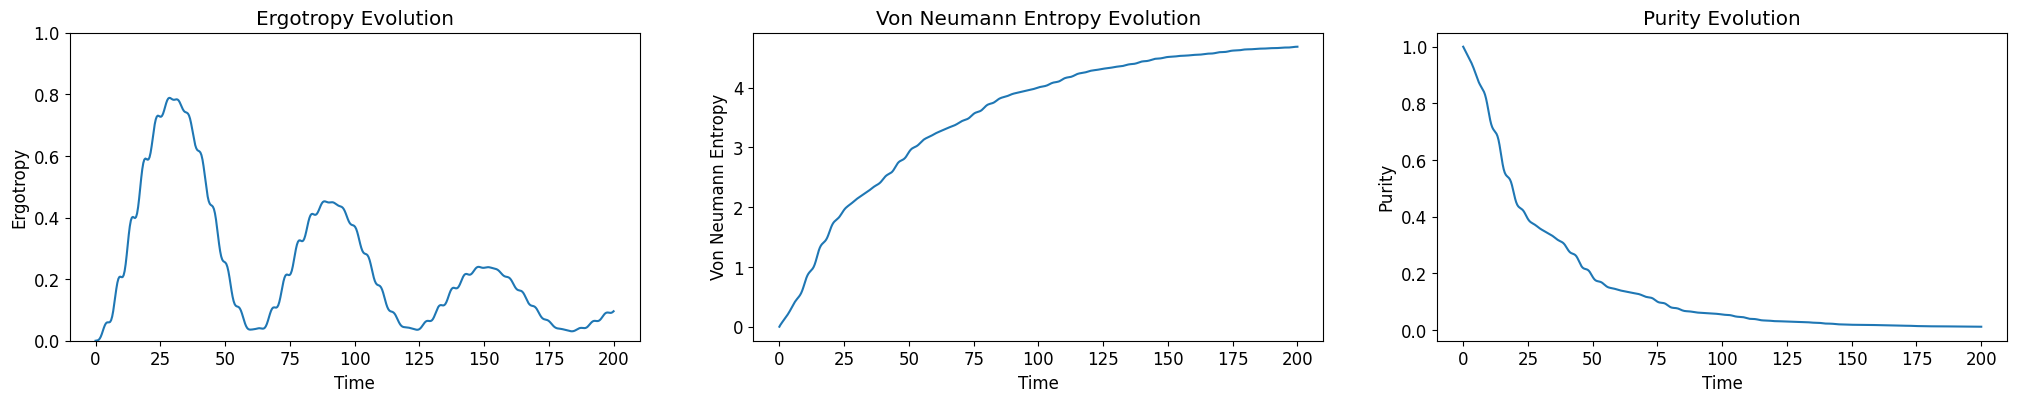

In [80]:
H0, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)
rho0 = eigenstates[0] * eigenstates[0].dag()

c_ops = get_scar_c_ops(N, basisList, gamma_phi=gamma_phi, gamma_1=gamma_1)
tlist, states = evolve_open(H0, H1, c_ops, rho0, args, t_max, t_idle=t_idle, n_charge=500, n_idle=500, options=None)
series_dict = battery_series(states, H0)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 4))

ax1.plot(tlist, series_dict['ergotropy'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Ergotropy')
ax1.set_ylim(0, 1)
ax1.set_title('Ergotropy Evolution')

ax2.plot(tlist, series_dict['S'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Von Neumann Entropy')
ax2.set_title('Von Neumann Entropy Evolution')

ax3.plot(tlist, series_dict['purity'])
ax3.set_xlabel('Time')
ax3.set_ylabel('Purity')
ax3.set_title('Purity Evolution')

Text(0.5, 1.0, 'Purity Evolution')

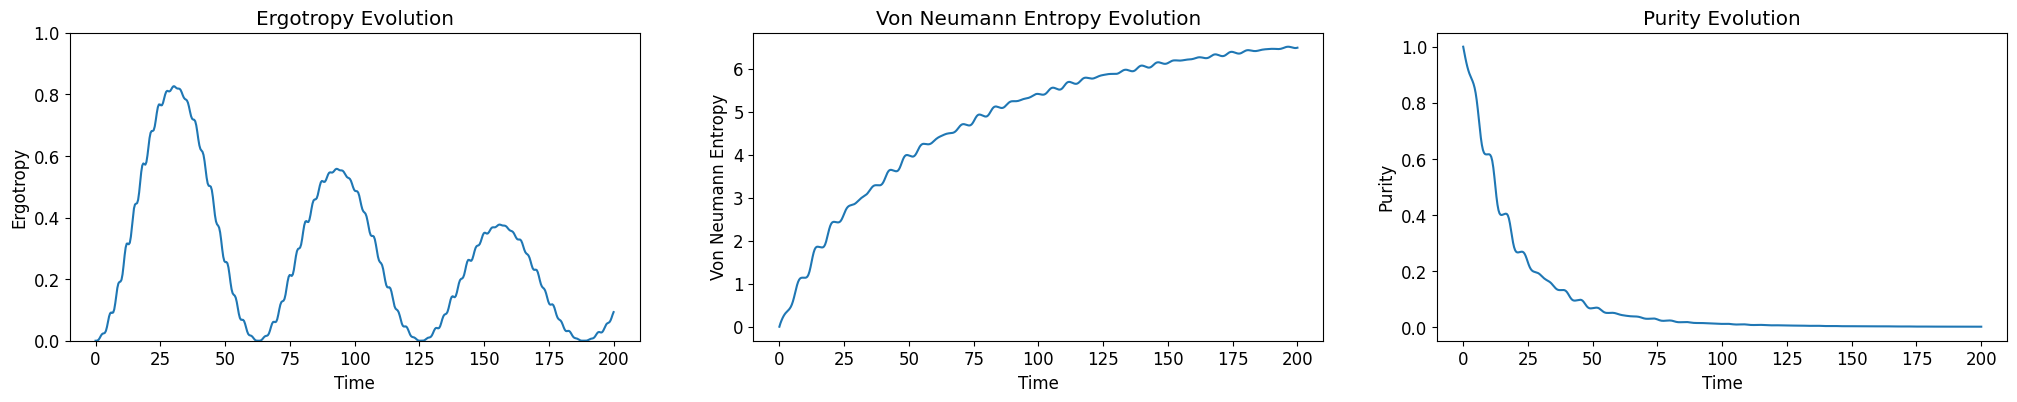

In [81]:
qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm)
c_ops = get_qubit_c_ops(gamma_phi=gamma_phi, gamma_1=gamma_1)
tlist, rho_list = evolve_qubits_open(qH0_list, qH1_list, c_ops, qargs, t_max, t_idle=t_idle, n_charge=500, n_idle=500, args_list=None, options=None)
series_dict = qubit_battery_series(rho_list, qH0_list)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 4))

ax1.plot(tlist, series_dict['ergotropy'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Ergotropy')
ax1.set_ylim(0, 1)
ax1.set_title('Ergotropy Evolution')

ax2.plot(tlist, series_dict['S'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Von Neumann Entropy')
ax2.set_title('Von Neumann Entropy Evolution')

ax3.plot(tlist, series_dict['purity'])
ax3.set_xlabel('Time')
ax3.set_ylabel('Purity')
ax3.set_title('Purity Evolution')